# Hyperparameter Tuning using GridSearchCV

## Objectives

- Tune the XGBoost model
- Find the optimal hyperparameters
- Compare tuned vs default performance
- Save the best model

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

In [2]:
X = pd.read_csv("../data/processed/X_train.csv")
y = pd.read_csv("../data/processed/y_train.csv")

In [3]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [4]:
param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [None, 10, 20],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]
}

In [5]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
grid = GridSearchCV(
    estimator=rf,

    param_grid=param_grid,

    scoring="r2",

    cv=kfold,

    n_jobs=-1,

    verbose=2
)

In [26]:
from sklearn.model_selection import cross_val_score

default_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(
    default_rf,
    X,
    y.values.ravel(),
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

In [17]:
grid.fit(
    X,
    y.values.ravel()
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See 

In [18]:
print("="*50)
print("Best Parameters")
print("="*50)

print(grid.best_params_)

Best Parameters
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [19]:
print("="*50)
print("Best CV Score")
print("="*50)

print(grid.best_score_)

Best CV Score
0.9939258339207436


In [20]:
results = pd.DataFrame(grid.cv_results_)

results = results[
    [
        "mean_test_score",
        "std_test_score",
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "rank_test_score"
    ]
]

results = results.sort_values(
    "rank_test_score"
)

display(results)

,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,rank_test_score
26,0.993926,0.001325,300,20,2,1,1
14,0.993921,0.001268,300,10,2,1,2
2,0.993916,0.001325,300,None,2,1,3
25,0.993915,0.001323,200,20,2,1,4
13,0.993906,0.001288,200,10,2,1,5
1,0.993896,0.001331,200,None,2,1,6
12,0.993894,0.001257,100,10,2,1,7
24,0.993863,0.001304,100,20,2,1,8
0,0.993857,0.001317,100,None,2,1,9
29,0.993761,0.001248,300,20,5,1,10


In [21]:
best_rf = grid.best_estimator_

joblib.dump(
    best_rf,
    "../models/random_forest_tuned.pkl"
)

['../models/random_forest_tuned.pkl']

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Default Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV R²": [
        rf_scores.mean(),
        grid.best_score_
    ]
})

display(comparison)

,Model,Mean CV R²
0,Default Random Forest,0.993857
1,Tuned Random Forest,0.993926


In [28]:
default_score = rf_scores.mean()
tuned_score = grid.best_score_

comparison = pd.DataFrame({
    "Model": [
        "Default Random Forest",
        "Tuned Random Forest"
    ],
    "Mean CV R²": [
        default_score,
        tuned_score
    ],
    "Improvement": [
        "-",
        f"{tuned_score - default_score:+.6f}"
    ]
})

display(comparison)

,Model,Mean CV R²,Improvement
0,Default Random Forest,0.993857,-
1,Tuned Random Forest,0.993926,+0.000069


analysing results via heat map

In [29]:
import matplotlib.pyplot as plt

heatmap_data = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators",
    aggfunc="max"
)

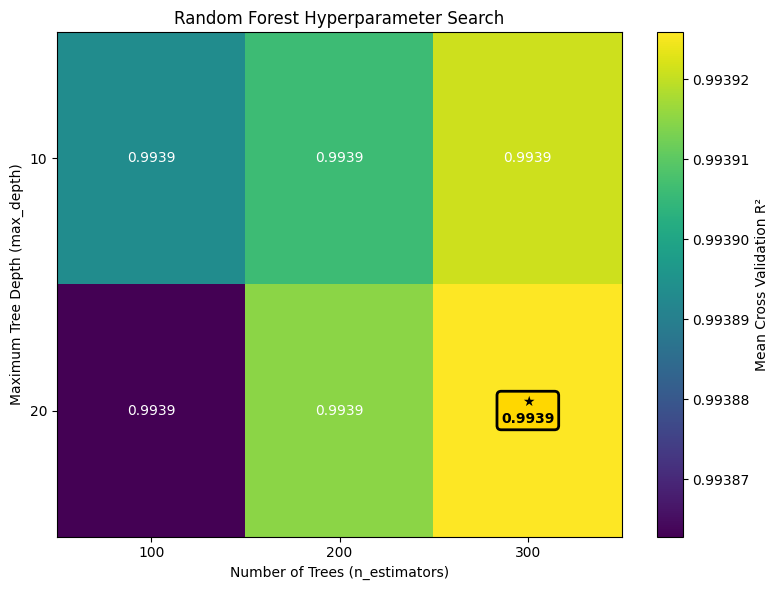

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot heatmap
im = ax.imshow(
    heatmap_data,
    cmap="viridis",
    aspect="auto"
)

# Axis ticks
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Labels
ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("Maximum Tree Depth (max_depth)")
ax.set_title("Random Forest Hyperparameter Search")

# Find the best-performing cell
best_row, best_col = np.unravel_index(
    np.nanargmax(heatmap_data.values),
    heatmap_data.shape
)

# Write values inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        # Highlight best cell
        if i == best_row and j == best_col:
            bbox = dict(
                boxstyle="round,pad=0.3",
                facecolor="gold",
                edgecolor="black",
                linewidth=2
            )
            color = "black"
            weight = "bold"
            text = f"★\n{value:.4f}"
        else:
            bbox = None
            color = "white"
            weight = "normal"
            text = f"{value:.4f}"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color=color,
            fontweight=weight,
            fontsize=10,
            bbox=bbox
        )

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Mean Cross Validation R²")

plt.tight_layout()
plt.show()

In [31]:
# Display Top 4 Hyperparameter Combinations

top4 = (
    results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_n_estimators",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf"
        ]
    ]
    .sort_values("rank_test_score")
    .head(4)
    .reset_index(drop=True)
)

# Rename columns for readability
top4.columns = [
    "Rank",
    "Mean CV R²",
    "Std Dev",
    "Trees",
    "Max Depth",
    "Min Samples Split",
    "Min Samples Leaf"
]

display(top4)

,Rank,Mean CV R²,Std Dev,Trees,Max Depth,Min Samples Split,Min Samples Leaf
0,1,0.993926,0.001325,300,20,2,1
1,2,0.993921,0.001268,300,10,2,1
2,3,0.993916,0.001325,300,None,2,1
3,4,0.993915,0.001323,200,20,2,1


In [32]:
print("="*60)
print("Random Forest Hyperparameter Tuning Completed")
print("="*60)

print(f"Best Parameters : {grid.best_params_}")
print(f"Best CV R²      : {grid.best_score_:.6f}")
print(f"Improvement     : {grid.best_score_ - rf_scores.mean():.6f}")

Random Forest Hyperparameter Tuning Completed
Best Parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²      : 0.993926
Improvement     : 0.000069
